# Stage A - Training the Convolutional VAE
Train the healer network to reconstruct clean images from noisy ImageNet-100 inputs.

In [1]:
import sys
import os
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Resolve project root robustly for notebook execution.
candidates = [
    Path('C:/Users/Akash/Desktop/SelfHealingNN'),
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / 'Desktop' / 'SelfHealingNN',
]

current = Path.cwd()
for _ in range(8):
    candidates.append(current)
    current = current.parent

project_root = None
for candidate in candidates:
    candidate = candidate.resolve()
    if (candidate / 'src').exists() and (candidate / 'configs').exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError(f"Could not resolve project root. cwd={Path.cwd()}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)
print(f"Project root: {project_root}")
print(f"Working directory: {os.getcwd()}")
print(f"Seed: {SEED}")

Project root: C:\Users\Akash\Desktop\SelfHealingNN
Working directory: C:\Users\Akash\Desktop\SelfHealingNN
Seed: 42


In [2]:
from pathlib import Path
import importlib
import yaml
import torch
import matplotlib.pyplot as plt
from torchinfo import summary

import src.dataset as dataset_module
import src.conv_vae as conv_vae_module
import src.train_vae as train_vae_module
import src.evaluate as evaluate_module

# Reload modules so notebook always uses latest source edits.
importlib.reload(dataset_module)
importlib.reload(conv_vae_module)
importlib.reload(train_vae_module)
importlib.reload(evaluate_module)

get_dataloaders = dataset_module.get_dataloaders
ConvVAE = conv_vae_module.ConvVAE
vae_loss = conv_vae_module.vae_loss
train_vae = train_vae_module.train_vae
compute_psnr = evaluate_module.compute_psnr
compute_ssim = evaluate_module.compute_ssim

In [3]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

requested_device = config.get('training', {}).get('device', 'cuda')
if str(requested_device).startswith('cuda') and torch.cuda.is_available():
    device = 'cuda'
    torch.backends.cudnn.benchmark = True
else:
    device = 'cpu'

model = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
model

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


ConvVAE(
  (encoder): ConvEncoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
      (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (flatten): Flatten(start_d

In [4]:
summary(model, input_size=(1, 3, 224, 224), depth=3)

Layer (type:depth-idx)                   Output Shape              Param #
ConvVAE                                  [1, 3, 224, 224]          --
├─ConvEncoder: 1-1                       [1, 256]                  --
│    └─Sequential: 2-1                   [1, 512, 14, 14]          --
│    │    └─Conv2d: 3-1                  [1, 64, 112, 112]         3,136
│    │    └─BatchNorm2d: 3-2             [1, 64, 112, 112]         128
│    │    └─LeakyReLU: 3-3               [1, 64, 112, 112]         --
│    │    └─Conv2d: 3-4                  [1, 128, 56, 56]          131,200
│    │    └─BatchNorm2d: 3-5             [1, 128, 56, 56]          256
│    │    └─LeakyReLU: 3-6               [1, 128, 56, 56]          --
│    │    └─Conv2d: 3-7                  [1, 256, 28, 28]          524,544
│    │    └─BatchNorm2d: 3-8             [1, 256, 28, 28]          512
│    │    └─LeakyReLU: 3-9               [1, 256, 28, 28]          --
│    │    └─Conv2d: 3-10                 [1, 512, 14, 14]          2,

In [5]:
def loss_fn(recon, target, mu, logvar, beta):
    total, parts = vae_loss(recon, target, mu, logvar, beta=beta)
    return total, parts

loss_fn

<function __main__.loss_fn(recon, target, mu, logvar, beta)>

In [8]:
import inspect

# Set to True to force fresh training and ignore old corrupted checkpoints
# IMPORTANT: Set this to True for this fix because old checkpoint was trained with wrong tensorspace!
force_fresh_start = True

dataset_root = Path(config['dataset']['root'])
if not dataset_root.is_absolute():
    dataset_root = (project_root / dataset_root).resolve()
if not dataset_root.exists():
    raise FileNotFoundError(f'Dataset root not found: {dataset_root}')

checkpoint_dir = project_root / 'models' / 'checkpoints' / 'vae'
latest_ckpt = checkpoint_dir / 'latest.pt'
if force_fresh_start and latest_ckpt.exists():
    latest_ckpt.unlink()
    print(f"[FIXED] Deleted old checkpoint to start fresh training")

train_loader, val_loader, test_loader = get_dataloaders(
    root=str(dataset_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['vae']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=True,
    noise_type='gaussian',
    noise_params={'std': config['noise']['gaussian_std']}
)

sig = inspect.signature(train_vae)
if 'checkpoint_dir' not in sig.parameters:
    raise RuntimeError('Outdated train_vae loaded in kernel. Re-run Cell 3 (imports) or restart kernel and run all.')

use_amp = bool(config['training'].get('amp', True)) and not bool(config['vae'].get('disable_amp_until_stable', False))
auto_resume = bool(config['training'].get('auto_resume', True)) and not force_fresh_start
print(f"[INFO] Config setting denormalize_targets: {config['vae'].get('denormalize_targets', 'NOT SET')}")
print(f"[INFO] This means VAE targets will be: {'denormalized [0,1]' if config['vae'].get('denormalize_targets') else 'normalized [-2,+2]'}")


[INFO] Config setting denormalize_targets: False
[INFO] This means VAE targets will be: normalized [-2,+2]


In [ ]:
history = train_vae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=config['vae']['epochs'],
    learning_rate=config['vae']['learning_rate'],
    beta=config['vae']['beta'],
    save_path=str(project_root / 'models' / 'conv_vae_best.pth'),
    patience=config['training']['early_stopping_patience'],
    checkpoint_dir=str(checkpoint_dir),
    checkpoint_interval=int(config['training'].get('checkpoint_interval', 2)),
    auto_resume=auto_resume,
    use_amp=use_amp,
    grad_clip_norm=float(config['training'].get('grad_clip_norm', 1.0)),
    denormalize_targets=bool(config['vae'].get('denormalize_targets', True)),
    beta_schedule=str(config['vae'].get('beta_schedule', 'constant')),
    beta_warmup_epochs=int(config['vae'].get('beta_warmup_epochs', 10)),
    early_stop_metric=str(config['training'].get('vae_early_stop_metric', 'val_recon')),
    recon_loss_type=str(config['vae'].get('recon_loss_type', 'smooth_l1')),
    huber_delta=float(config['vae'].get('huber_delta', 1.0)),
)

print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Auto resume: {auto_resume}")
print(f"AMP enabled: {use_amp}")
print(f"Fresh start forced: {force_fresh_start}")

In [7]:
epochs = range(1, len(history['train_total']) + 1)
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs, history['train_recon'], label='Train')
plt.plot(epochs, history['val_recon'], label='Val')
plt.title('Recon Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs, history['train_kl'], label='Train')
plt.plot(epochs, history['val_kl'], label='Val')
plt.title('KL Loss')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs, history['train_total'], label='Train')
plt.plot(epochs, history['val_total'], label='Val')
plt.title('Total Loss')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs, history.get('train_psnr', []), label='Train PSNR')
plt.plot(epochs, history.get('val_psnr', []), label='Val PSNR')
plt.title('PSNR (dB)')
plt.legend()

plt.tight_layout()
plt.show()

if history.get('lr') and history.get('beta'):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['lr'])
    plt.title('Learning Rate')
    plt.yscale('log')
    plt.grid(alpha=0.25)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['beta'])
    plt.title('Effective Beta')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

NameError: name 'history' is not defined

C:\Users\Akash\AppData\Local\Temp\ipykernel_14092\2549261522.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(project_root / 'models'

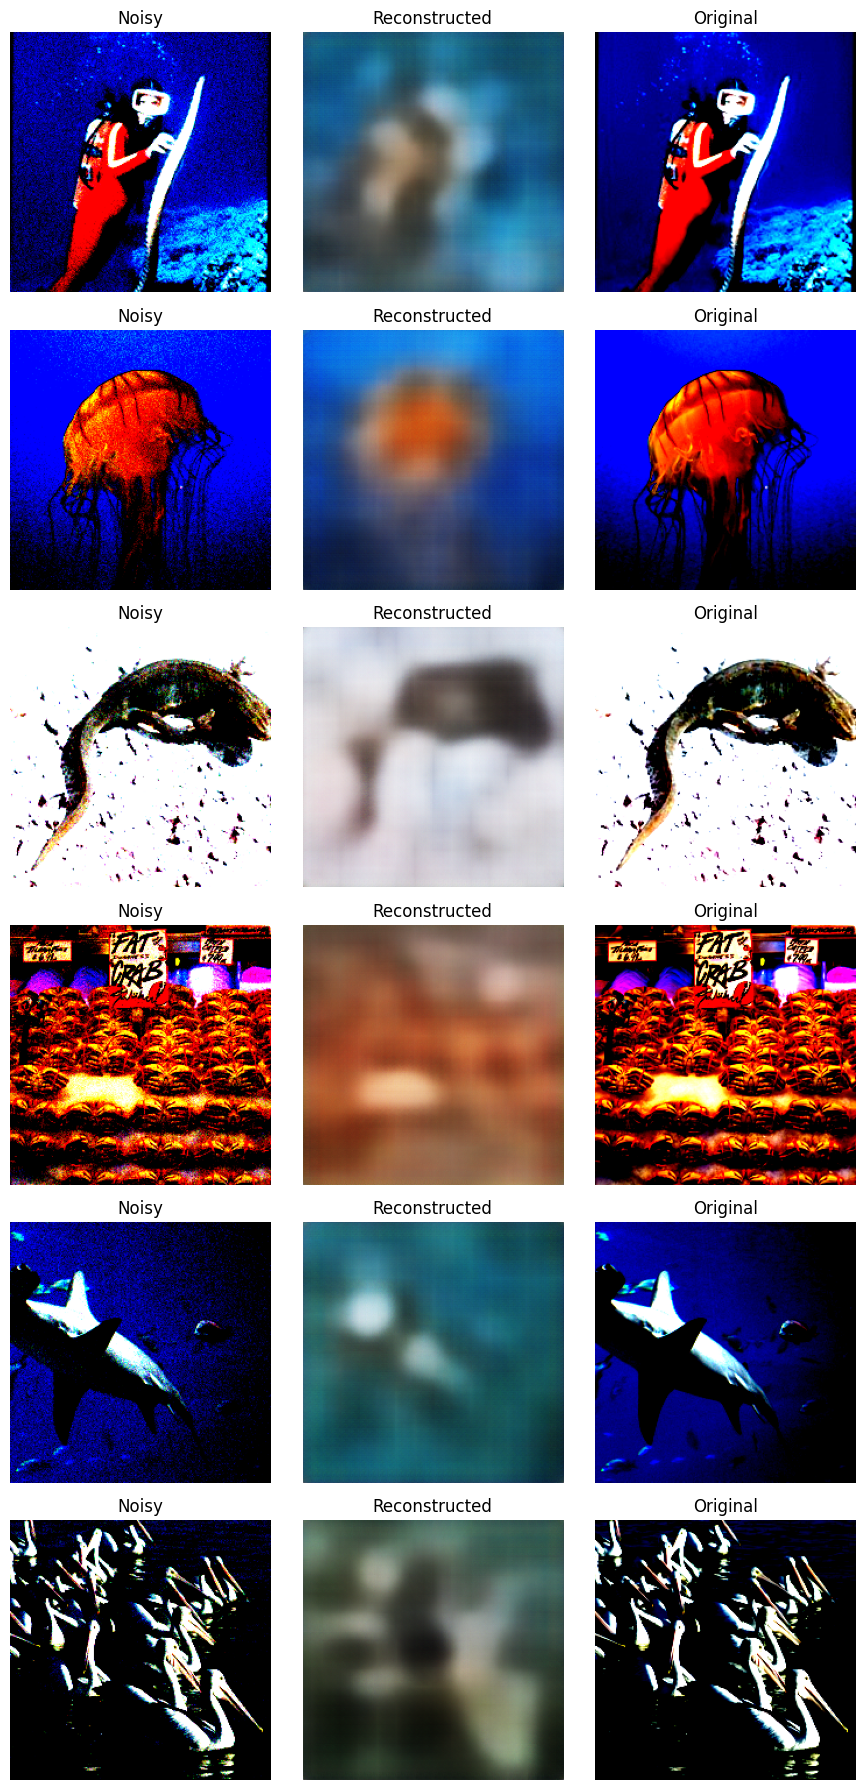

In [ ]:
model.load_state_dict(torch.load(str(project_root / 'models' / 'conv_vae_best.pth'), map_location=device))
model.eval()

noisy, clean, _ = next(iter(test_loader))
noisy = noisy.to(device)
clean = clean.to(device)
with torch.no_grad():
    recon, _, _ = model(noisy)

n = min(6, noisy.size(0))
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    axes[i, 0].imshow(noisy[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 0].set_title('Noisy')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(recon[i].detach().cpu().permute(1, 2, 0).numpy())
    axes[i, 1].set_title('Reconstructed')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(clean[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 2].set_title('Original')
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
psnr_values = [compute_psnr(clean[i], recon[i]) for i in range(min(16, clean.size(0)))]
ssim_values = [compute_ssim(clean[i], recon[i]) for i in range(min(16, clean.size(0)))]
print('Avg PSNR:', sum(psnr_values) / len(psnr_values))
print('Avg SSIM:', sum(ssim_values) / len(ssim_values))

if history.get('val_psnr'):
    best_epoch = int(np.argmax(history['val_psnr'])) + 1
    print(f'Best validation PSNR epoch: {best_epoch}')
    print(f"Best val PSNR: {history['val_psnr'][best_epoch - 1]:.3f} dB")

Avg PSNR: 13.0314644814326
Avg SSIM: 0.019696939561981708
Best validation PSNR epoch: 2
Best val PSNR: 17.643 dB


## Summary
The ConvVAE healer is trained, tracked with reconstruction and KL losses, and validated through qualitative reconstructions plus PSNR/SSIM metrics.